In [21]:
!pip install gymnasium moviepy --quiet


In [22]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
import io
import base64
import glob
from IPython.display import HTML, display
from gym.wrappers import RecordVideo


In [23]:
def show_video():
    mp4list = glob.glob('video/*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display(HTML(data=f'''
        <video alt="Recorded Video" autoplay loop controls style="height: 400px;">
        <source src="data:video/mp4;base64,{encoded.decode('ascii')}" type="video/mp4" />
        </video>'''))
    else:
        print("Could not find video")


In [24]:
# Initialize environment
env = gym.make("CartPole-v1", render_mode="rgb_array")  # Use "rgb_array" for Colab
gamma = 0.99  # Discount factor
epsilon = 0.1  # Exploration rate
alpha = 0.1  # Learning rate
returns = {}  # Store returns
policy = {}   # Policy mapping states to actions
visit_counts = {}  # Track state-action visits

def monte_carlo_agent(state):
    state_tuple = tuple(np.round(state.astype(float), 1))  # Ensure valid key
    if state_tuple not in policy:
        policy[state_tuple] = random.choice([0, 1])  # Random initialization

    # Epsilon-greedy action selection: explore with probability epsilon, otherwise exploit
    if random.uniform(0, 1) < epsilon:
        return random.choice([0, 1])
    else:
        return policy[state_tuple]

# Validate with a sample observation
sample_observation, _ = env.reset()
sample_observation = np.array(sample_observation)  # Ensure NumPy array
chosen_action = monte_carlo_agent(sample_observation)
print("Sample Observation:", sample_observation)
print("Chosen Action:", chosen_action)


Sample Observation: [-0.00163196 -0.00395949 -0.01379689 -0.02998926]
Chosen Action: 0


In [25]:
num_episodes = 15000
episode_rewards = []

# Fixing the issue in the update loop
def generate_episode():
    episode = []
    state, _ = env.reset()
    state = np.array(state, dtype=np.float32)  # Ensure correct dtype
    done = False
    while not done:
        action = monte_carlo_agent(state)
        next_state, reward, done, _, _ = env.step(action)
        next_state = np.array(next_state, dtype=np.float32)  # Convert to float32
        episode.append((state, action, reward))
        state = next_state
    return episode

for _ in range(num_episodes):
    episode = generate_episode()
    G = 0
    visited_states = set()

    for t in reversed(range(len(episode))):
        state, action, reward = episode[t]
        G = gamma * G + reward
        state_tuple = tuple(np.round(state.astype(float), 1))

        if (state_tuple, action) not in visited_states:
            visited_states.add((state_tuple, action))

            if (state_tuple, action) not in returns:
                returns[(state_tuple, action)] = []
            returns[(state_tuple, action)].append(G)

            # Update the policy with the average of returns, introducing learning rate
            average_return = np.mean(returns[(state_tuple, action)])
            current_policy = policy[state_tuple]
            # Update policy to be the action with max average return (integer)
            policy[state_tuple] = max([0, 1], key=lambda a: np.mean(returns.get((state_tuple, a), [0])))

    episode_rewards.append(sum([x[2] for x in episode]))


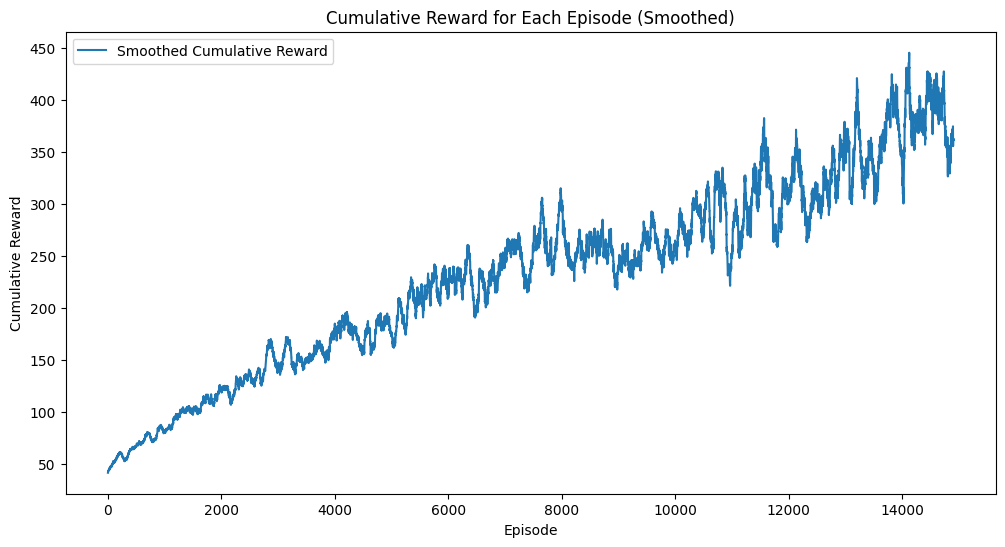

Average cumulative reward: 231.28186666666667
Is my agent good enough? True


In [26]:
# Calculate the moving average (smoothing)
window_size = 100  # Adjust this window size based on how smooth you want the curve
smoothed_rewards = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')

# Plot cumulative rewards with smoothing
plt.figure(figsize=(12, 6))
plt.plot(smoothed_rewards, label="Smoothed Cumulative Reward")
plt.title('Cumulative Reward for Each Episode (Smoothed)')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward')
plt.legend()
plt.show()

# Print final evaluation of agent's performance
average_reward = np.mean(episode_rewards)
print("Average cumulative reward:", average_reward)
print("Is my agent good enough?", average_reward > 195)



In [27]:
# Render and display video in Colab
def show_video():
    import glob
    mp4list = glob.glob('video/*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display(HTML(data='''<video alt="test" autoplay
                    loop controls style="height: 400px;">
                    <source src="data:video/mp4;base64,{0}" type="video/mp4" />
                 </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

# Record and render one episode
env = RecordVideo(gym.make("CartPole-v1", render_mode="rgb_array"), "./video")
state, _ = env.reset()
done = False

while not done:
    action = monte_carlo_agent(state)
    state, _, done, _, _ = env.step(action)

env.close()
show_video()  # Display recorded video in Colab

Moviepy - Building video /content/video/rl-video-episode-0.mp4.
Moviepy - Writing video /content/video/rl-video-episode-0.mp4



Moviepy - Done !
Moviepy - video ready /content/video/rl-video-episode-0.mp4
